In [3]:
%load_ext autoreload
%autoreload 2

In [29]:
import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython.display import display, Markdown, Math
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import (
    CompareMeans,
    DescrStatsW
)

In [36]:
load_data.reload()

funnel table loaded!
duration table loaded!
transition table loaded!
completion time table loaded!
all tables reloaded!


In [5]:
df_duration = load_data.load("duration")
df_funnel = load_data.load("funnel")
df_duration.head()

duration table loaded!
funnel table loaded!


,client_id,variation,process_step,date_time,duration_sec
0,555,Test,start,2017-04-15 12:57:56+00:00,7.0
1,555,Test,step_1,2017-04-15 12:58:03+00:00,32.0
2,555,Test,step_2,2017-04-15 12:58:35+00:00,99.0
3,555,Test,step_3,2017-04-15 13:00:14+00:00,20.0
4,555,Test,confirm,2017-04-15 13:00:34+00:00,NaN


In [ ]:
df_completion_time = load_data.load("completion_time")
df_completion_time_test = df_completion_time[df_completion_time.variation == "Test"]
df_completion_time_control = df_completion_time[df_completion_time.variation == "Control"]

completion_time table loaded!


In [32]:
#display(df_completion_time.describe())
print("test group")
display(df_completion_time_test.describe())
print("control group")
display(df_completion_time_control.describe())

test group


,client_id,calendar_completion_time_sec,active_completion_time_sec
count,1.840300e+04,1.840300e+04,18403.000000
mean,4.986265e+06,2.316692e+05,415.083247
std,2.873178e+06,8.474110e+05,502.455362
min,5.550000e+02,3.200000e+01,0.000000
25%,2.495754e+06,1.600000e+02,152.000000
50%,5.032714e+06,2.810000e+02,254.000000
75%,7.425334e+06,6.675000e+02,471.000000
max,9.999729e+06,7.810368e+06,8148.000000


control group


,client_id,calendar_completion_time_sec,active_completion_time_sec
count,1.530300e+04,1.530300e+04,15303.000000
mean,5.026369e+06,3.195735e+05,420.273803
std,2.870112e+06,1.030986e+06,449.247076
min,1.195000e+03,3.300000e+01,0.000000
25%,2.549167e+06,1.910000e+02,178.000000
50%,5.040733e+06,3.220000e+02,282.000000
75%,7.495186e+06,7.560000e+02,485.000000
max,9.998346e+06,8.373894e+06,7755.000000


In [18]:
display(
    Markdown(
        f"""
### Hypothesis

$$
H_0: \\mu_t = \\mu_c
$$

$$
H_1: \\mu_t < \\mu_c
$$
"""))


### Hypothesis

$$
H_0: \mu_t = \mu_c
$$

$$
H_1: \mu_t < \mu_c
$$


In [39]:
# Welch's t-test, two samples, σ² unknown and consider as unequal(could do a test if neccessary)

t_stat, p_value = ttest_ind(
    df_completion_time_test['active_completion_time_sec'],
    df_completion_time_control['active_completion_time_sec'],
    equal_var=False,
    alternative='less'
)

print(f"Z: {t_stat:.2f}")
print(f"P value: {p_value:.4f}")

Z: -1.00
P value: 0.1585


In [30]:
cm = CompareMeans(
    DescrStatsW(df_completion_time_test['active_completion_time_sec'].dropna()),
    DescrStatsW(df_completion_time_control['active_completion_time_sec'].dropna())
)

ci_low, ci_high = cm.tconfint_diff(
    alpha=0.05,
    usevar='unequal'   # Welch
)

test_mean = df_completion_time_test['active_completion_time_sec'].mean()
control_mean = df_completion_time_control['active_completion_time_sec'].mean()

diff = test_mean - control_mean

print(f"Mean Difference (Test - Control): {diff:.2f} sec")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

Mean Difference (Test - Control): -5.19 sec
95% CI: [-15.36, 4.98]


The Test group showed a lower average completion time than the Control group, with a mean difference of **−5.19 seconds** (Test − Control).

However, the 95% confidence interval for the mean difference was **[-15.36, 4.98] seconds**, which includes zero.

Consistent with the confidence interval, Welch's t-test indicated that the difference was not statistically significant (**p = 0.1585 > α = 0.05**).

Therefore, we fail to reject the null hypothesis and do not have sufficient evidence to conclude that the new process reduced completion time.

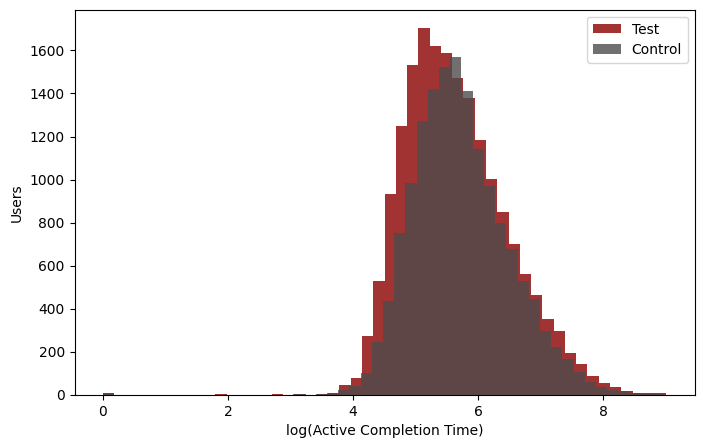

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(
        df_completion_time_test['active_completion_time_sec']
    ),
    bins=50,
    alpha=0.8,
    color="#8B0000",
    label='Test'
)

plt.hist(
    np.log1p(
        df_completion_time_control['active_completion_time_sec']
    ),
    bins=50,
    alpha=0.8,
    color='#4F4B4B',
    label='Control'
)

plt.legend()
plt.xlabel('log(Active Completion Time)')
plt.ylabel('Users')
plt.show()

The Test group shows a slight leftward shift in log completion times, suggesting marginally faster task completion. However, the strong overlap between the two distributions indicates that the difference is small and aligns with the non-significant Welch's t-test result (p = 0.1585).